# 01 — Policy Evaluation
**Week 4 | Dynamic Programming**

**Policy Evaluation** answers: *How good is a given policy π?*

We iteratively apply the Bellman expectation equation until V converges:

$$V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma V_k(s') \right]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# ---- Reuse Grid World from Week 3 ----
class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size = size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits = {(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        """Return list of (prob, next_s, reward, done)."""
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:       return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:       return [(1.0, ns,  -5.0, True)]
        return [(1.0, ns, -0.1, False)]

env = GridWorld()

In [2]:
def policy_evaluation(env, policy, gamma=0.99, theta=1e-6, max_iter=1000):
    V = np.zeros(env.n_states())
    history = [V.copy()]
    for iteration in range(max_iter):
        delta = 0.0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = 0.0
            for a in range(env.n_actions()):
                for prob, ns, reward, done in env.transitions(s, a):
                    v += policy[s, a] * prob * (reward + (0 if done else gamma * V[ns]))  # fixed: V[ns]
            V_new[s] = v
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        history.append(V.copy())
        if delta < theta:
            print(f"Converged in {iteration+1} iterations (Δ={delta:.2e})")
            break
    return V, history

In [3]:
# Uniform random policy
n_s, n_a = env.n_states(), env.n_actions()
uniform_policy = np.ones((n_s, n_a)) / n_a

V, history = policy_evaluation(env, uniform_policy)

Converged in 81 iterations (Δ=8.45e-07)


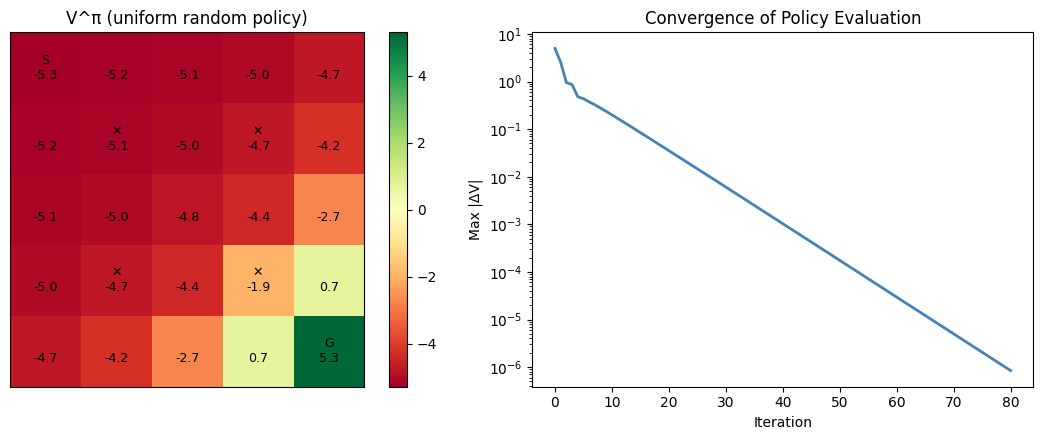

In [4]:
# Visualise final value function
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Heatmap
im = axes[0].imshow(V.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=axes[0])
for r in range(5):
    for c in range(5):
        label = ''
        if (r,c)==env.goal: label='G'
        elif (r,c)==env.start: label='S'
        elif (r,c) in env.pits: label='✕'
        axes[0].text(c, r, f'{label}\n{V[r*5+c]:.1f}', ha='center', va='center', fontsize=9)
axes[0].set_title('V^π (uniform random policy)'); axes[0].set_xticks([]); axes[0].set_yticks([])

# Convergence curve
max_delta = [np.max(np.abs(history[i+1]-history[i])) for i in range(len(history)-1)]
axes[1].semilogy(max_delta, color='steelblue', linewidth=2)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Max |ΔV|')
axes[1].set_title('Convergence of Policy Evaluation')
plt.tight_layout(); plt.show()

## ✅ Exercises
1. Try γ=0.5, γ=0.9, γ=0.999. How does the value function shape change?
2. Create a policy that always moves RIGHT. Evaluate it. What happens to states on the rightmost column?
3. **Challenge**: implement **in-place** policy evaluation (update V[s] immediately instead of V_new). Does it converge faster?

## Question 1.

In [5]:
for gamma in [0.5, 0.9, 0.999]:
    V_g, _ = policy_evaluation(env, uniform_policy, gamma=gamma)
    print(f"\nγ={gamma}\n", V_g.reshape(5,5).round(2))

Converged in 18 iterations (Δ=5.39e-07)

γ=0.5
 [[-0.72 -1.76 -1.03 -1.76 -0.71]
 [-1.76 -1.26 -2.87 -1.24 -1.7 ]
 [-1.03 -2.87 -1.52 -2.81 -0.57]
 [-1.76 -1.24 -2.81 -0.48  1.29]
 [-0.71 -1.7  -0.57  1.29  5.27]]
Converged in 53 iterations (Δ=8.62e-07)

γ=0.9
 [[-3.13 -3.61 -3.41 -3.54 -2.89]
 [-3.61 -3.59 -4.14 -3.37 -3.08]
 [-3.41 -4.14 -3.67 -3.79 -1.83]
 [-3.54 -3.37 -3.79 -1.35  1.02]
 [-2.89 -3.08 -1.83  1.02  5.41]]
Converged in 85 iterations (Δ=8.87e-07)

γ=0.999
 [[-5.62 -5.43 -5.38 -5.22 -4.99]
 [-5.43 -5.37 -5.12 -4.9  -4.38]
 [-5.38 -5.12 -4.9  -4.49 -2.87]
 [-5.22 -4.9  -4.49 -2.02  0.64]
 [-4.99 -4.38 -2.87  0.64  5.27]]


Converged in 18 iterations (Δ=5.39e-07)
Converged in 53 iterations (Δ=8.62e-07)
Converged in 85 iterations (Δ=8.87e-07)


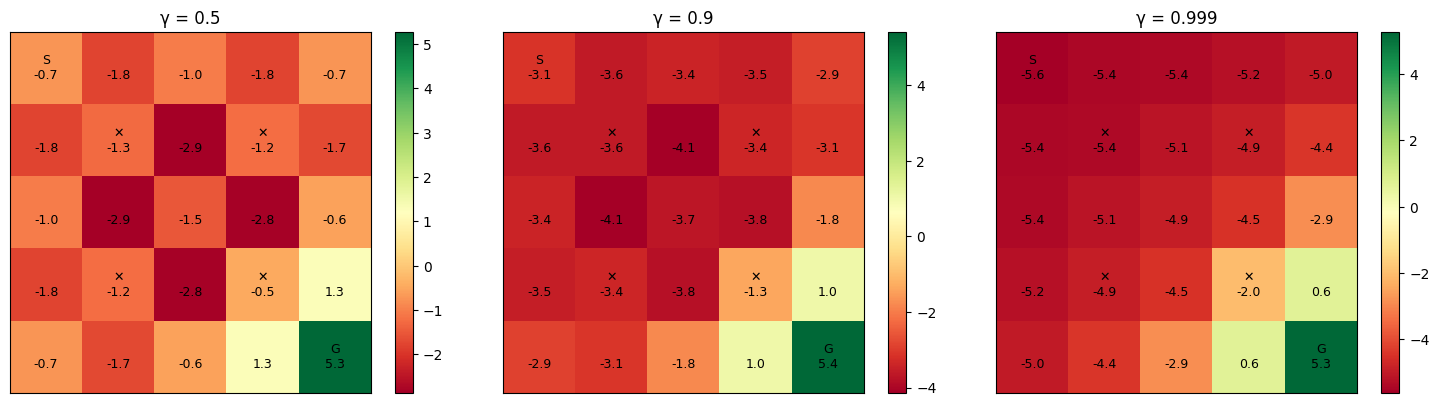

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, gamma in zip(axes, [0.5, 0.9, 0.999]):
    V_g, _ = policy_evaluation(env, uniform_policy, gamma=gamma)
    im = ax.imshow(V_g.reshape(5,5), cmap='RdYlGn')
    plt.colorbar(im, ax=ax)
    for r in range(5):
        for c in range(5):
            label = ''
            if (r,c)==env.goal: label='G'
            elif (r,c)==env.start: label='S'
            elif (r,c) in env.pits: label='✕'
            ax.text(c, r, f'{label}\n{V_g[r*5+c]:.1f}', ha='center', va='center', fontsize=9)
    ax.set_title(f'γ = {gamma}')
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

γ = 0.5 : values are small and range from about -2 to 5. The grid looks mostly flat/orange. Only the goal (5.3) stands out. The rest of the states have very similar low values, meaning the agent barely feels the goal from far away.

γ = 0.9 : values spread more, ranging from about -4 to 5. You can see a clearer color difference between states. The goal pulls nearby states up and the pits drag nearby states down more noticeably.

γ = 0.999 : values range from about -5.6 to 5.3. The grid shows the strongest contrast. States far from the goal are deeply negative and the pits create a bigger red zone around them. The gradient from top left to bottom right is very visible.

## Question 2.

In [8]:
right_policy = np.zeros((n_s, n_a))
right_policy[:, 3] = 1.0  # action 3 = RIGHT
V_right, _ = policy_evaluation(env, right_policy)


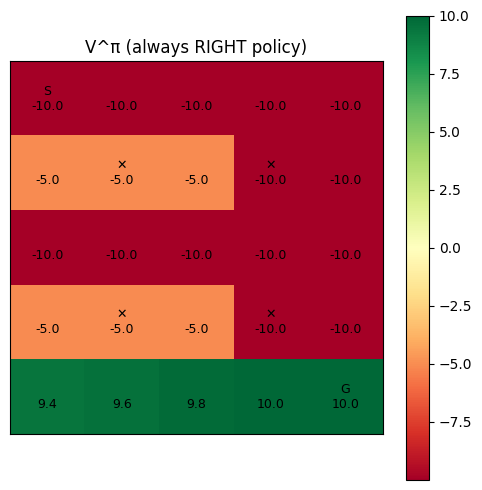

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(V_right.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=ax)
for r in range(5):
    for c in range(5):
        label = ''
        if (r,c)==env.goal: label='G'
        elif (r,c)==env.start: label='S'
        elif (r,c) in env.pits: label='✕'
        ax.text(c, r, f'{label}\n{V_right[r*5+c]:.1f}', ha='center', va='center', fontsize=9)
ax.set_title('V^π (always RIGHT policy)')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

The always RIGHT policy is terrible for most of the grid. Almost every state gets -10.0 because the agent either gets stuck hitting the wall repeatedly or walks straight into pits.
The only states with good values are the bottom row (9.4 to 10.0) because moving right there leads directly to the goal.
So the rightmost column (except the goal) is basically a dead end the agent hits the wall, stays there, and keeps collecting -0.1 penalties forever.

## Question 3.

In [10]:
def policy_evaluation_inplace(env, policy, gamma=0.99, theta=1e-6, max_iter=1000):
    V = np.zeros(env.n_states())
    for iteration in range(max_iter):
        delta = 0.0
        for s in range(env.n_states()):
            v_old = V[s]
            v = 0.0
            for a in range(env.n_actions()):
                for prob, ns, reward, done in env.transitions(s, a):
                    v += policy[s, a] * prob * (reward + (0 if done else gamma * V[ns]))
            V[s] = v
            delta = max(delta, abs(V[s] - v_old))
        if delta < theta:
            print(f"In-place converged in {iteration+1} iterations")
            break
    return V

Converged in 81 iterations (Δ=8.45e-07)
In-place converged in 60 iterations


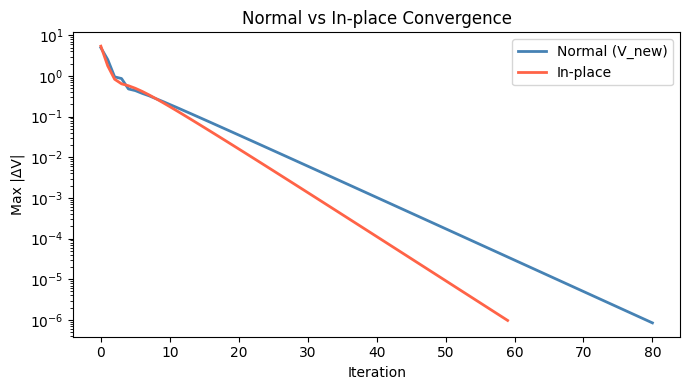

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

V_normal, history_normal = policy_evaluation(env, uniform_policy)
max_delta_normal = [np.max(np.abs(history_normal[i+1] - history_normal[i])) for i in range(len(history_normal)-1)]
ax.semilogy(max_delta_normal, label='Normal (V_new)', color='steelblue', linewidth=2)

V_ip = np.zeros(env.n_states())
deltas_ip = []
for iteration in range(1000):
    delta = 0.0
    for s in range(env.n_states()):
        v_old = V_ip[s]
        v = 0.0
        for a in range(env.n_actions()):
            for prob, ns, reward, done in env.transitions(s, a):
                v += uniform_policy[s, a] * prob * (reward + (0 if done else 0.99 * V_ip[ns]))
        V_ip[s] = v
        delta = max(delta, abs(V_ip[s] - v_old))
    deltas_ip.append(delta)
    if delta < 1e-6:
        print(f"In-place converged in {iteration+1} iterations")
        break

ax.semilogy(deltas_ip, label='In-place', color='tomato', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Max |ΔV|')
ax.set_title('Normal vs In-place Convergence')
ax.legend()
plt.tight_layout()
plt.show()

yes , In-place converged faster .